# Probability of AND

Based on [Probability for Computer Scientists — Probability of AND](https://chrispiech.github.io/probabilityForComputerScientists/en/part1/prob_and/)

The probability of the *and* of two events $E$ and $F$, written $P(E \text{ and } F)$, is the probability that **both** events occur.

**Equivalent notations:** $P(E \text{ and } F) = P(EF) = P(E \cap F) = P(E, F)$

How we calculate it depends on whether the events are **independent** or **dependent**.

In [21]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
from matplotlib.colors import to_rgba
from itertools import combinations
from math import comb, factorial

from libs.venn import venn, Color

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
print('Setup complete!')

Setup complete!


---
## 1 · Visualizing $P(E \cap F)$

The AND probability is the **overlap** — the region where both events occur simultaneously.

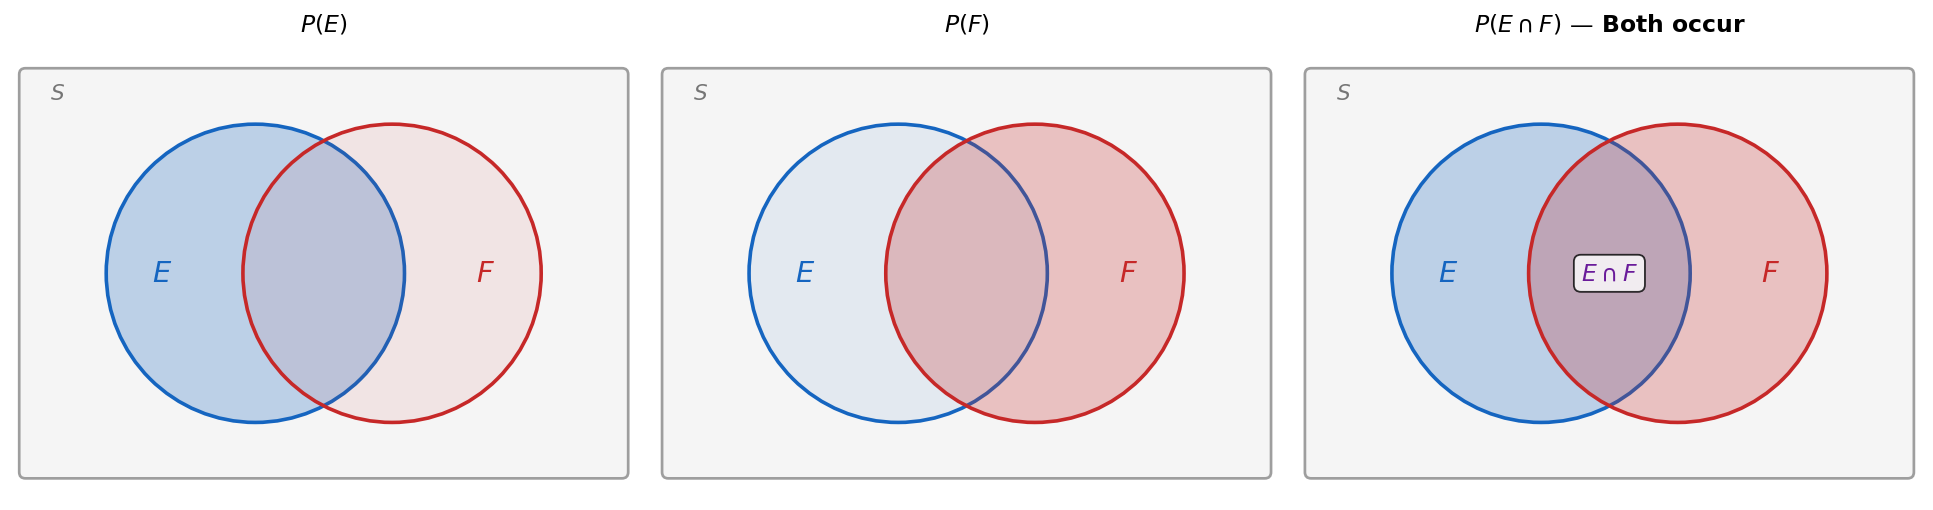

In [22]:
# --- Visual: P(E ∩ F) is the overlap region ---

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Helper: draw two overlapping circles
def draw_venn(ax, highlight='both', title=''):
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

    # Sample space rectangle
    rect = FancyBboxPatch((-2.4, -1.6), 4.8, 3.2, boxstyle='round,pad=0.05',
                          facecolor='#F5F5F5', edgecolor='#9E9E9E', lw=1.5)
    ax.add_patch(rect)
    ax.text(-2.2, 1.4, '$S$', fontsize=12, color='#757575')

    # Circle colors based on highlight
    c_e = to_rgba('#1565C0', 0.25 if highlight in ('both', 'E') else 0.08)
    c_f = to_rgba('#C62828', 0.25 if highlight in ('both', 'F') else 0.08)
    c_int = to_rgba('#6A1B9A', 0.45 if highlight == 'both' else 0.08)

    # E circle
    circ_e = Circle((-0.55, 0), 1.2, facecolor=c_e, edgecolor='#1565C0', lw=2)
    ax.add_patch(circ_e)
    ax.text(-1.3, 0, '$E$', fontsize=16, fontweight='bold', color='#1565C0',
            ha='center', va='center')

    # F circle
    circ_f = Circle((0.55, 0), 1.2, facecolor=c_f, edgecolor='#C62828', lw=2)
    ax.add_patch(circ_f)
    ax.text(1.3, 0, '$F$', fontsize=16, fontweight='bold', color='#C62828',
            ha='center', va='center')

    # Intersection highlight
    if highlight == 'both':
        from matplotlib.patches import Wedge
        import matplotlib.path as mpath
        # Just label the center region
        ax.text(0, 0, '$E \\cap F$', fontsize=13, fontweight='bold',
                color='#6A1B9A', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

configs = [
    ('E', '$P(E)$'),
    ('F', '$P(F)$'),
    ('both', '$P(E \\cap F)$ — Both occur'),
]

for ax, (h, t) in zip(axes, configs):
    draw_venn(ax, highlight=h, title=t)

plt.tight_layout()
plt.show()

---
## 2 · AND with Independent Events

When events are **independent**, knowing one happened tells you nothing about the other.
The AND becomes simple multiplication:

$$\boxed{\text{If } E \perp F: \quad P(E \cap F) = P(E) \cdot P(F)}$$

This extends to $n$ mutually independent events:

$$P(E_1 \cap E_2 \cap \cdots \cap E_n) = \prod_{i=1}^{n} P(E_i)$$

In [23]:
# --- Example: Two fair dice (independent) ---

S = [(d1, d2) for d1 in range(1, 7) for d2 in range(1, 7)]

E = {o for o in S if o[0] % 2 == 0}   # die 1 is even
F = {o for o in S if o[1] >= 4}         # die 2 ≥ 4
E_and_F = E & F

P_E = len(E) / len(S)
P_F = len(F) / len(S)
P_EF = len(E_and_F) / len(S)

print('AND with Independent Events: Two Fair Dice')
print('=' * 50)
print(f'E = die₁ is even          → P(E) = {P_E:.4f}')
print(f'F = die₂ ≥ 4              → P(F) = {P_F:.4f}')
print(f'E ∩ F = die₁ even AND die₂ ≥ 4')
print(f'    |E ∩ F| = {len(E_and_F)} outcomes out of {len(S)}')
print(f'    P(E ∩ F) = {P_EF:.4f}')
print(f'    P(E)·P(F) = {P_E:.4f} × {P_F:.4f} = {P_E * P_F:.4f}')
print(f'\n    P(E ∩ F) == P(E)·P(F)? {abs(P_EF - P_E * P_F) < 1e-10}  → Independent ✓')

AND with Independent Events: Two Fair Dice
E = die₁ is even          → P(E) = 0.5000
F = die₂ ≥ 4              → P(F) = 0.5000
E ∩ F = die₁ even AND die₂ ≥ 4
    |E ∩ F| = 9 outcomes out of 36
    P(E ∩ F) = 0.2500
    P(E)·P(F) = 0.5000 × 0.5000 = 0.2500

    P(E ∩ F) == P(E)·P(F)? True  → Independent ✓


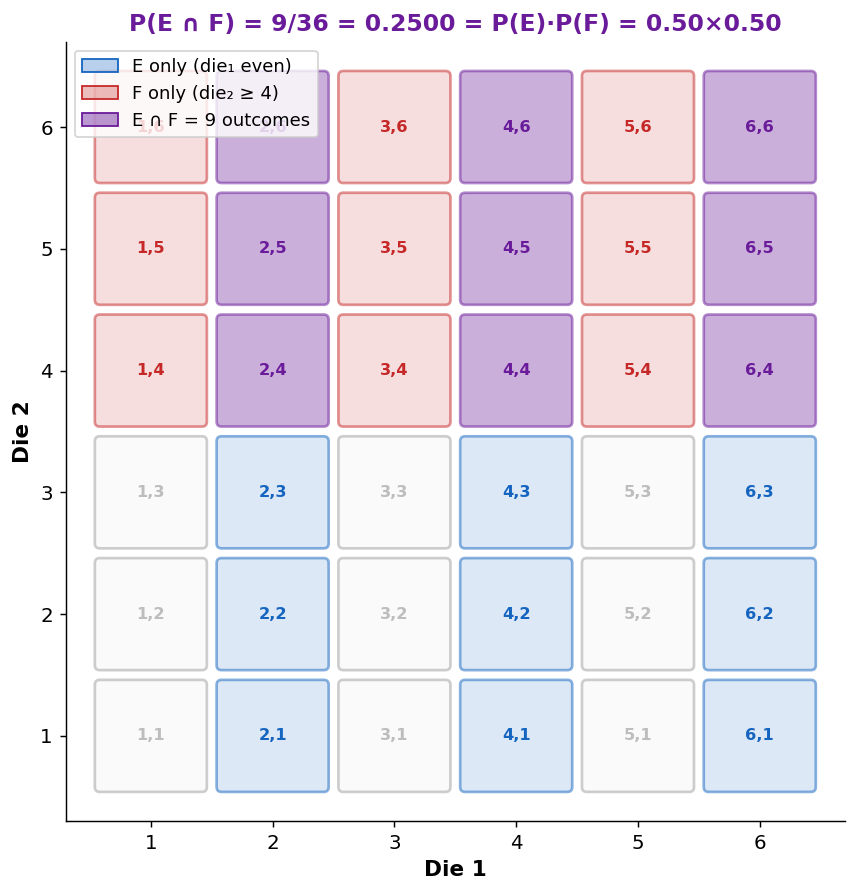

In [24]:
# --- Visual: 6×6 grid showing E, F, and E∩F ---

fig, ax = plt.subplots(figsize=(8, 7))

for d1 in range(1, 7):
    for d2 in range(1, 7):
        outcome = (d1, d2)
        in_E = outcome in E
        in_F = outcome in F

        if in_E and in_F:
            color = '#6A1B9A'   # both — purple
            alpha = 0.35
            label_color = '#6A1B9A'
        elif in_E:
            color = '#1565C0'   # E only — blue
            alpha = 0.15
            label_color = '#1565C0'
        elif in_F:
            color = '#C62828'   # F only — red
            alpha = 0.15
            label_color = '#C62828'
        else:
            color = '#9E9E9E'   # neither
            alpha = 0.05
            label_color = '#BDBDBD'

        rect = FancyBboxPatch((d1 - 0.42, d2 - 0.42), 0.84, 0.84,
            boxstyle='round,pad=0.04', facecolor=to_rgba(color, alpha),
            edgecolor=to_rgba(color, 0.5), lw=1.5)
        ax.add_patch(rect)
        ax.text(d1, d2, f'{d1},{d2}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=label_color)

ax.set_xlim(0.3, 6.7)
ax.set_ylim(0.3, 6.7)
ax.set_xlabel('Die 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Die 2', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 7))
ax.set_yticks(range(1, 7))
ax.set_aspect('equal')
ax.spines[['top', 'right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=to_rgba('#1565C0', 0.3), edgecolor='#1565C0', label=f'E only (die₁ even)'),
    Patch(facecolor=to_rgba('#C62828', 0.3), edgecolor='#C62828', label=f'F only (die₂ ≥ 4)'),
    Patch(facecolor=to_rgba('#6A1B9A', 0.45), edgecolor='#6A1B9A', label=f'E ∩ F = {len(E_and_F)} outcomes'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

ax.set_title(f'P(E ∩ F) = {len(E_and_F)}/{len(S)} = {P_EF:.4f} = P(E)·P(F) = {P_E:.2f}×{P_F:.2f}',
             fontsize=13, fontweight='bold', color='#6A1B9A')
plt.tight_layout()
plt.show()

---
## 3 · Proof: Independence → Product Rule

We derive the product rule from the definitions of conditional probability and independence:

| Step | Expression | Reason |
|------|-----------|--------|
| 1 | $P(E \mid F) = \dfrac{P(E \cap F)}{P(F)}$ | Definition of conditional probability |
| 2 | $P(E) = \dfrac{P(E \cap F)}{P(F)}$ | Since $E \perp F$, $P(E \mid F) = P(E)$ |
| 3 | $P(E \cap F) = P(E) \cdot P(F)$ | Multiply both sides by $P(F)$ |

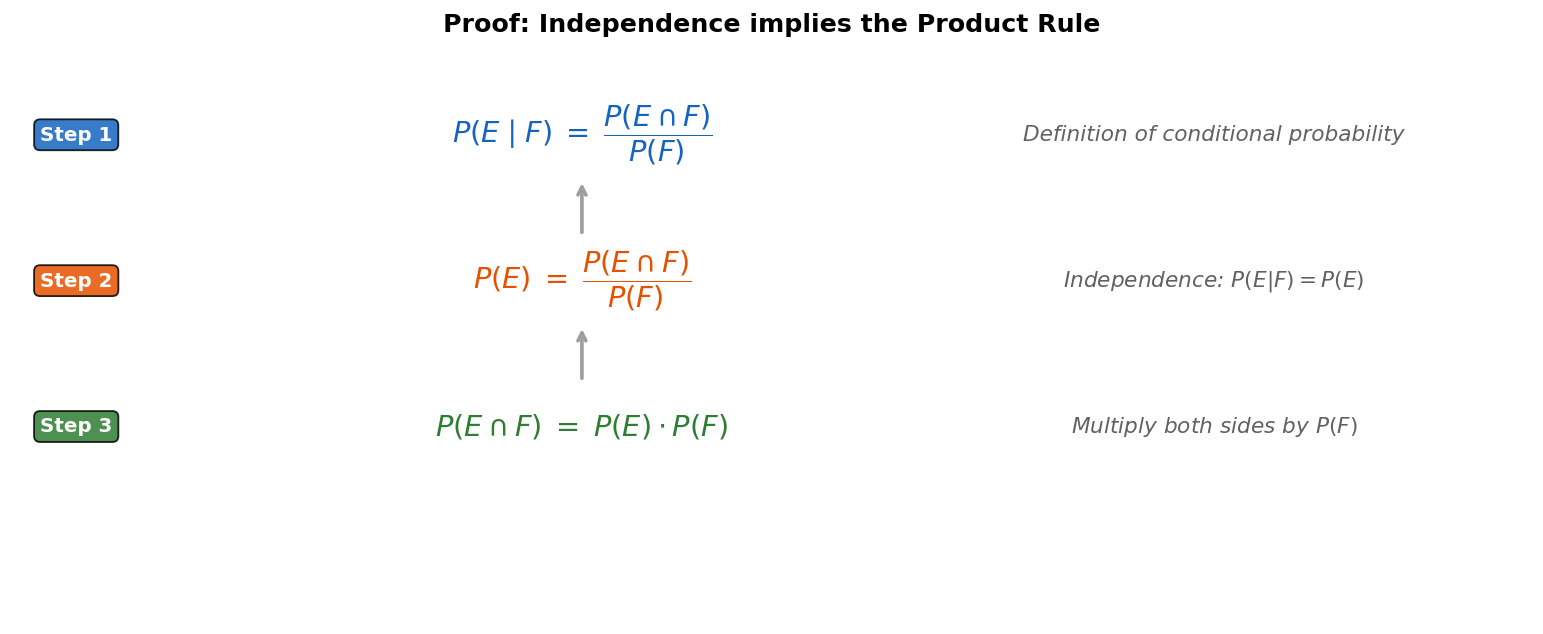

In [25]:
# --- Visual: step-by-step proof ---

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')
ax.set_xlim(0, 12)
ax.set_ylim(-1, 6)

steps = [
    (5.0, r'$P(E \mid F) \;=\; \dfrac{P(E \cap F)}{P(F)}$',
     'Definition of conditional probability', '#1565C0'),
    (3.2, r'$P(E) \;=\; \dfrac{P(E \cap F)}{P(F)}$',
     'Independence: $P(E|F) = P(E)$', '#E65100'),
    (1.4, r'$P(E \cap F) \;=\; P(E) \cdot P(F)$',
     'Multiply both sides by $P(F)$', '#2E7D32'),
]

for y, formula, reason, color in steps:
    # Formula on left
    ax.text(4.5, y, formula, fontsize=16, ha='center', va='center',
            color=color, fontweight='bold')
    # Reason on right
    ax.text(9.5, y, reason, fontsize=12, ha='center', va='center',
            color='#616161', style='italic')
    # Step number
    ax.text(0.5, y, f'Step {steps.index((y, formula, reason, color)) + 1}',
            fontsize=11, ha='center', va='center', fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.85))

    # Arrow between steps
    if y > 1.5:
        ax.annotate('', xy=(4.5, y - 0.55), xytext=(4.5, y - 1.25),
                    arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=2))

ax.set_title('Proof: Independence implies the Product Rule',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4 · Extended Product Rule — $n$ Independent Events

For $n$ **mutually independent** events, probabilities multiply:

$$P(E_1 \cap E_2 \cap \cdots \cap E_n) = P(E_1) \cdot P(E_2) \cdots P(E_n) = \prod_{i=1}^{n} P(E_i)$$

**Example:** What is the probability of getting heads on 10 independent fair coin flips?

In [26]:
# --- n independent coin flips ---

print('Extended Product Rule: n Independent Coin Flips')
print('=' * 55)

p_head = 0.5
n_vals = [1, 2, 3, 5, 10, 20, 50]

print(f'\n{"n flips":>8} {"P(all heads)":>18} {"Fraction":>16}')
print('-' * 45)
for n in n_vals:
    p_all = p_head ** n
    print(f'{n:>8} {p_all:>18.10f} {f"1/{2**n}":>16}')

print(f'\nWith each independent flip, probability halves: (1/2)^n')

Extended Product Rule: n Independent Coin Flips

 n flips       P(all heads)         Fraction
---------------------------------------------
       1       0.5000000000              1/2
       2       0.2500000000              1/4
       3       0.1250000000              1/8
       5       0.0312500000             1/32
      10       0.0009765625           1/1024
      20       0.0000009537        1/1048576
      50       0.0000000000 1/1125899906842624

With each independent flip, probability halves: (1/2)^n


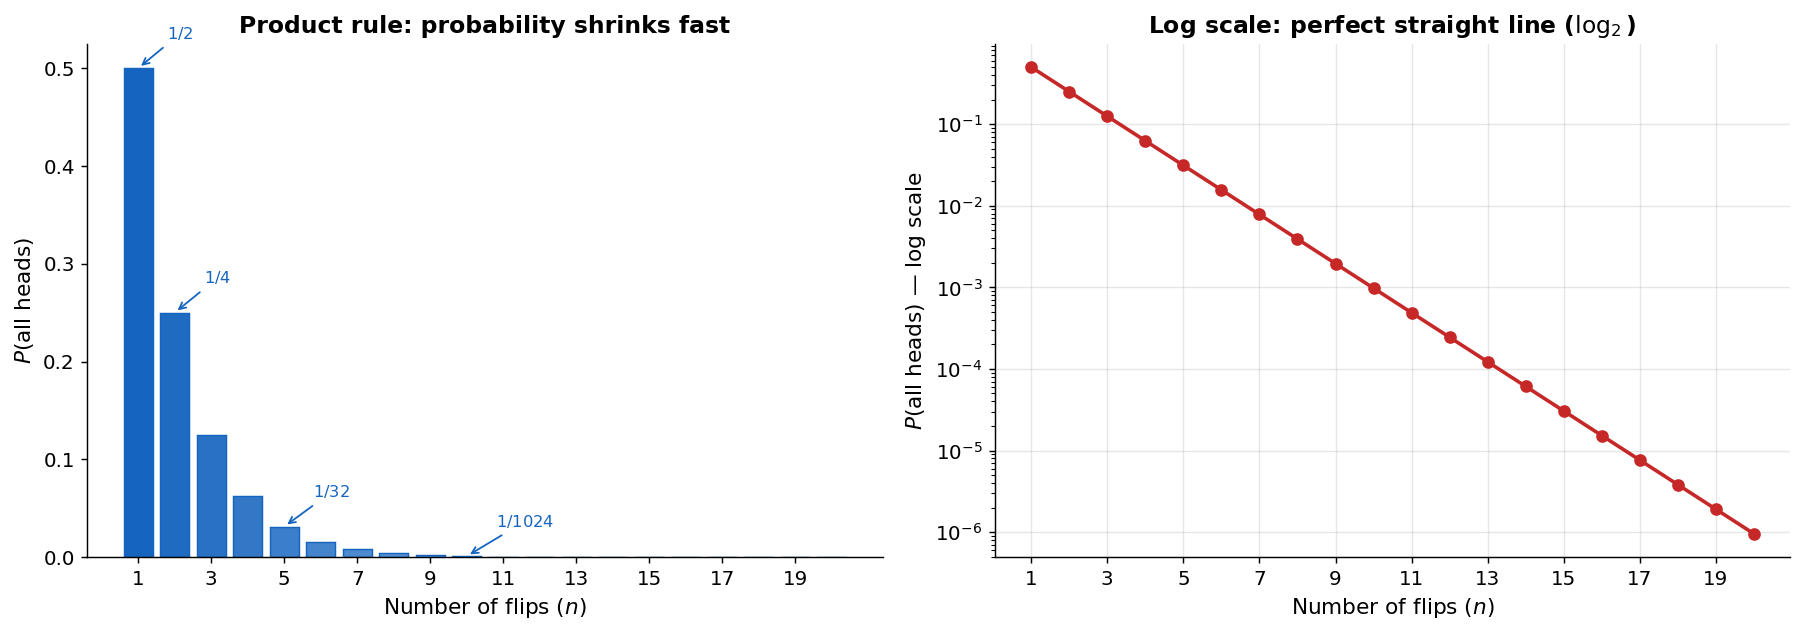

In [27]:
# --- Visual: probability shrinking with independent events ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_range = np.arange(1, 21)
p_all_heads = 0.5 ** n_range

# Panel 1: Linear scale
ax = axes[0]
bars = ax.bar(n_range, p_all_heads, color=[to_rgba('#1565C0', 0.2 + 0.8 * (1 - i/20))
              for i, _ in enumerate(n_range)], edgecolor='#1565C0', lw=0.8)
ax.set_xlabel('Number of flips ($n$)', fontsize=12)
ax.set_ylabel('$P$(all heads)', fontsize=12)
ax.set_title('Product rule: probability shrinks fast', fontsize=13, fontweight='bold')
ax.set_xticks(n_range[::2])
ax.spines[['top', 'right']].set_visible(False)

# Annotate first few
for n in [1, 2, 5, 10]:
    ax.annotate(f'$1/{2**n}$', xy=(n, 0.5**n), xytext=(n + 0.8, 0.5**n + 0.03),
                fontsize=9, fontweight='bold', color='#1565C0',
                arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1))

# Panel 2: Log scale
ax = axes[1]
ax.plot(n_range, p_all_heads, 'o-', color='#C62828', lw=2, markersize=6)
ax.set_yscale('log')
ax.set_xlabel('Number of flips ($n$)', fontsize=12)
ax.set_ylabel('$P$(all heads) — log scale', fontsize=12)
ax.set_title('Log scale: perfect straight line ($\\log_2$)', fontsize=13, fontweight='bold')
ax.set_xticks(n_range[::2])
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 5 · AND with Dependent Events — The Chain Rule

When events are **dependent**, we cannot simply multiply marginal probabilities.
Instead, we use the **chain rule**, derived directly from the definition of conditional probability:

$$\boxed{P(E \cap F) = P(E \mid F) \cdot P(F) = P(F \mid E) \cdot P(E)}$$

Intuitively: the probability of both happening = probability of $F$ happening × probability of $E$ *given that* $F$ happened.

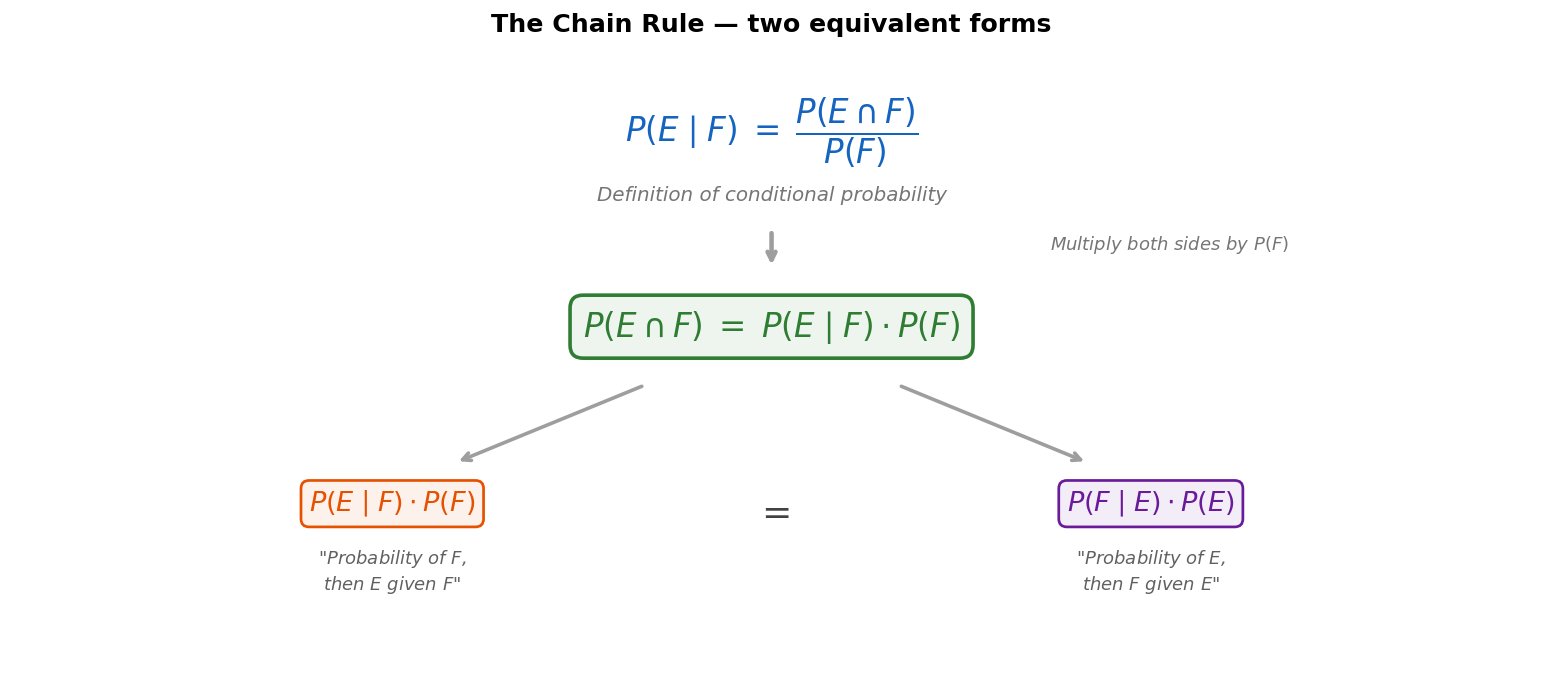

In [28]:
# --- Chain Rule derivation visual ---

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.axis('off')
ax.set_xlim(0, 12)
ax.set_ylim(-0.5, 6)

# Start: conditional probability definition
ax.text(6, 5.2, r'$P(E \mid F) \;=\; \dfrac{P(E \cap F)}{P(F)}$',
        fontsize=18, ha='center', va='center', color='#1565C0', fontweight='bold')
ax.text(6, 4.5, 'Definition of conditional probability',
        fontsize=11, ha='center', color='#757575', style='italic')

# Arrow down
ax.annotate('', xy=(6, 3.8), xytext=(6, 4.2),
            arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=2.5))
ax.text(8.2, 4.0, 'Multiply both sides by $P(F)$',
        fontsize=10, color='#757575', style='italic')

# Result: chain rule
ax.text(6, 3.2, r'$P(E \cap F) \;=\; P(E \mid F) \cdot P(F)$',
        fontsize=18, ha='center', va='center', color='#2E7D32', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=to_rgba('#2E7D32', 0.08),
                  edgecolor='#2E7D32', lw=2))

# Fork: show both directions
ax.annotate('', xy=(3.5, 1.8), xytext=(5, 2.6),
            arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=2))
ax.annotate('', xy=(8.5, 1.8), xytext=(7, 2.6),
            arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=2))

# Direction 1
ax.text(3.0, 1.3, r'$P(E \mid F) \cdot P(F)$',
        fontsize=15, ha='center', color='#E65100', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=to_rgba('#E65100', 0.08),
                  edgecolor='#E65100', lw=1.5))
ax.text(3.0, 0.5, '"Probability of $F$,\nthen $E$ given $F$"',
        fontsize=10, ha='center', color='#616161', style='italic')

# Direction 2
ax.text(9.0, 1.3, r'$P(F \mid E) \cdot P(E)$',
        fontsize=15, ha='center', color='#6A1B9A', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=to_rgba('#6A1B9A', 0.08),
                  edgecolor='#6A1B9A', lw=1.5))
ax.text(9.0, 0.5, '"Probability of $E$,\nthen $F$ given $E$"',
        fontsize=10, ha='center', color='#616161', style='italic')

# Equals sign between
ax.text(6.0, 1.3, '$=$', fontsize=20, ha='center', va='center',
        fontweight='bold', color='#424242')

ax.set_title('The Chain Rule — two equivalent forms',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6 · Worked Example: Drawing Cards Without Replacement

Drawing from a standard 52-card deck **without replacement** creates dependent events:
the first draw changes the composition of the deck for the second draw.

**Question:** What is $P(\text{1st card is Ace AND 2nd card is Ace})$?

In [29]:
# --- Cards without replacement (dependent) ---

print('Drawing Cards WITHOUT Replacement (Dependent)')
print('=' * 55)

# E = first card is Ace, F = second card is Ace
P_E_card = 4 / 52
P_F_given_E = 3 / 51    # after removing one Ace, 3 left in 51
P_EF_chain = P_E_card * P_F_given_E

print(f'E = 1st card is Ace')
print(f'F = 2nd card is Ace')
print(f'')
print(f'P(E) = 4/52 = {P_E_card:.6f}')
print(f'P(F|E) = 3/51 = {P_F_given_E:.6f}  (one Ace removed)')
print(f'')
print(f'Chain Rule: P(E ∩ F) = P(F|E) · P(E)')
print(f'          = {P_F_given_E:.6f} × {P_E_card:.6f}')
print(f'          = {P_EF_chain:.6f}')
print(f'          = 12/2652 = 1/221')
print(f'')

# Verify with counting
ways_two_aces = 4 * 3           # first Ace × second Ace (ordered)
total_ordered = 52 * 51         # total ordered pairs
P_EF_counting = ways_two_aces / total_ordered
print(f'Verification by counting:')
print(f'  Ordered pairs of Aces: 4 × 3 = {ways_two_aces}')
print(f'  Total ordered pairs:   52 × 51 = {total_ordered}')
print(f'  P = {ways_two_aces}/{total_ordered} = {P_EF_counting:.6f} ✓')

Drawing Cards WITHOUT Replacement (Dependent)
E = 1st card is Ace
F = 2nd card is Ace

P(E) = 4/52 = 0.076923
P(F|E) = 3/51 = 0.058824  (one Ace removed)

Chain Rule: P(E ∩ F) = P(F|E) · P(E)
          = 0.058824 × 0.076923
          = 0.004525
          = 12/2652 = 1/221

Verification by counting:
  Ordered pairs of Aces: 4 × 3 = 12
  Total ordered pairs:   52 × 51 = 2652
  P = 12/2652 = 0.004525 ✓


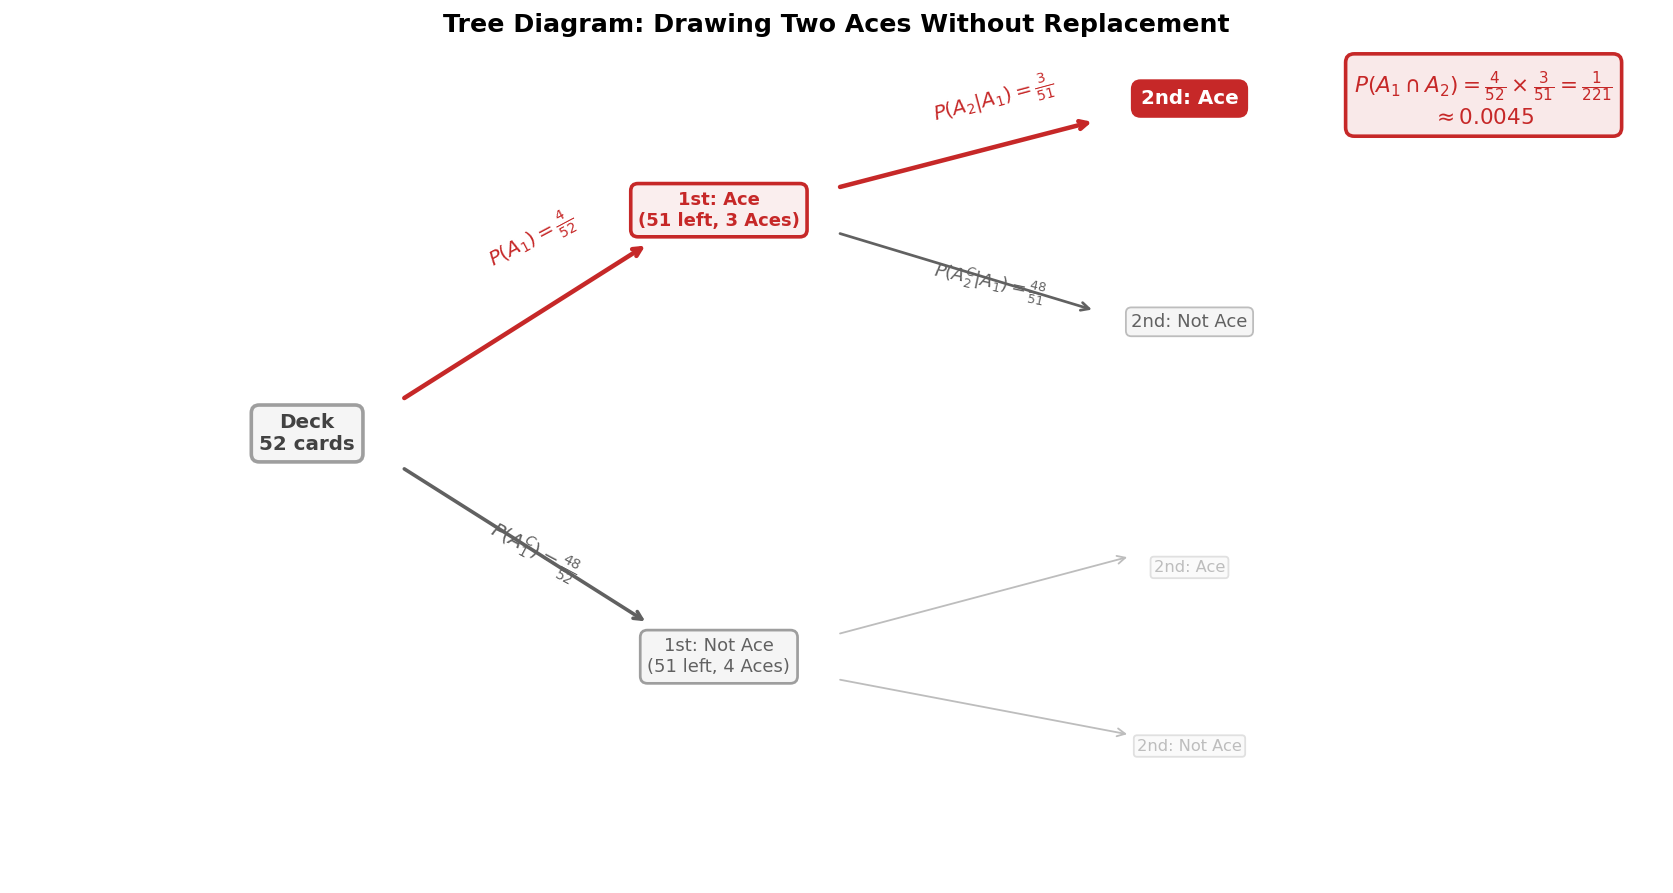

In [30]:
# --- Visual: tree diagram for card drawing ---

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')
ax.set_xlim(-1, 13)
ax.set_ylim(-0.5, 7)

# Root
root = (1.5, 3.5)
ax.text(*root, 'Deck\n52 cards', ha='center', va='center', fontsize=11,
        fontweight='bold', color='#424242',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F5F5', edgecolor='#9E9E9E', lw=2))

# Level 1: First draw
ace1 = (5, 5.5)
not_ace1 = (5, 1.5)

# Branch: first is Ace
ax.annotate('', xy=(ace1[0] - 0.6, ace1[1] - 0.3), xytext=(root[0] + 0.8, root[1] + 0.3),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=2.5))
ax.text(3.0, 5.0, '$P(A_1) = \\frac{4}{52}$', fontsize=11, color='#C62828',
        fontweight='bold', rotation=28)

ax.text(*ace1, '1st: Ace\n(51 left, 3 Aces)', ha='center', va='center', fontsize=10,
        fontweight='bold', color='#C62828',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=to_rgba('#C62828', 0.08),
                  edgecolor='#C62828', lw=2))

# Branch: first is not Ace
ax.annotate('', xy=(not_ace1[0] - 0.6, not_ace1[1] + 0.3), xytext=(root[0] + 0.8, root[1] - 0.3),
            arrowprops=dict(arrowstyle='->', color='#616161', lw=2))
ax.text(3.0, 2.2, '$P(A_1^C) = \\frac{48}{52}$', fontsize=11, color='#616161',
        fontweight='bold', rotation=-28)

ax.text(*not_ace1, '1st: Not Ace\n(51 left, 4 Aces)', ha='center', va='center', fontsize=10,
        color='#616161',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F5F5', edgecolor='#9E9E9E', lw=1.5))

# Level 2 from Ace branch
ace2 = (9, 6.5)
not_ace2 = (9, 4.5)

# Ace then Ace
ax.annotate('', xy=(ace2[0] - 0.8, ace2[1] - 0.2), xytext=(ace1[0] + 1.0, ace1[1] + 0.2),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=2.5))
ax.text(6.8, 6.3, '$P(A_2|A_1) = \\frac{3}{51}$', fontsize=11, color='#C62828',
        fontweight='bold', rotation=15)

ax.text(*ace2, '2nd: Ace', ha='center', va='center', fontsize=11,
        fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#C62828', edgecolor='#C62828', lw=2))

# Result
ax.text(11.5, 6.5,
        f'$P(A_1 \\cap A_2) = \\frac{{4}}{{52}} \\times \\frac{{3}}{{51}} = \\frac{{1}}{{221}}$\n'
        f'$\\approx {1/221:.4f}$',
        ha='center', va='center', fontsize=12, fontweight='bold', color='#C62828',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=to_rgba('#C62828', 0.1),
                  edgecolor='#C62828', lw=2))

# Ace then not Ace
ax.annotate('', xy=(not_ace2[0] - 0.8, not_ace2[1] + 0.1), xytext=(ace1[0] + 1.0, ace1[1] - 0.2),
            arrowprops=dict(arrowstyle='->', color='#616161', lw=1.5))
ax.text(6.8, 4.7, '$P(A_2^C|A_1) = \\frac{48}{51}$', fontsize=10, color='#616161',
        rotation=-12)
ax.text(*not_ace2, '2nd: Not Ace', ha='center', va='center', fontsize=10, color='#616161',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5', edgecolor='#BDBDBD', lw=1))

# Level 2 from Not Ace branch (dimmed)
for y, label, prob in [(2.3, '2nd: Ace', '$\\frac{4}{51}$'), (0.7, '2nd: Not Ace', '$\\frac{47}{51}$')]:
    ax.annotate('', xy=(8.5, y + 0.1), xytext=(not_ace1[0] + 1.0, not_ace1[1] + (0.2 if y > 2 else -0.2)),
                arrowprops=dict(arrowstyle='->', color='#BDBDBD', lw=1))
    ax.text(9, y, label, ha='center', va='center', fontsize=9, color='#BDBDBD',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#FAFAFA', edgecolor='#E0E0E0', lw=1))

ax.set_title('Tree Diagram: Drawing Two Aces Without Replacement',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7 · Independent vs Dependent: Side by Side

Compare drawing **with replacement** (independent) vs **without replacement** (dependent).

In [31]:
# --- Comparison: with vs without replacement ---

print('With vs Without Replacement')
print('=' * 55)

# WITHOUT replacement (dependent)
P_ace1 = 4 / 52
P_ace2_given_ace1 = 3 / 51
P_both_without = P_ace1 * P_ace2_given_ace1

# WITH replacement (independent)
P_ace_any = 4 / 52
P_both_with = P_ace_any * P_ace_any

print(f'\nWITHOUT replacement (dependent):')
print(f'  P(Ace₁ ∩ Ace₂) = P(Ace₁) · P(Ace₂|Ace₁)')
print(f'                  = 4/52 × 3/51 = {P_both_without:.6f}')
print(f'')
print(f'WITH replacement (independent):')
print(f'  P(Ace₁ ∩ Ace₂) = P(Ace₁) · P(Ace₂)')
print(f'                  = 4/52 × 4/52 = {P_both_with:.6f}')
print(f'')
print(f'Difference: {abs(P_both_with - P_both_without):.6f}')
print(f'With replacement is {P_both_with / P_both_without:.2f}× more likely')
print(f'\nKey: removing an Ace reduced the chance of a second Ace!')

With vs Without Replacement

WITHOUT replacement (dependent):
  P(Ace₁ ∩ Ace₂) = P(Ace₁) · P(Ace₂|Ace₁)
                  = 4/52 × 3/51 = 0.004525

WITH replacement (independent):
  P(Ace₁ ∩ Ace₂) = P(Ace₁) · P(Ace₂)
                  = 4/52 × 4/52 = 0.005917

Difference: 0.001392
With replacement is 1.31× more likely

Key: removing an Ace reduced the chance of a second Ace!


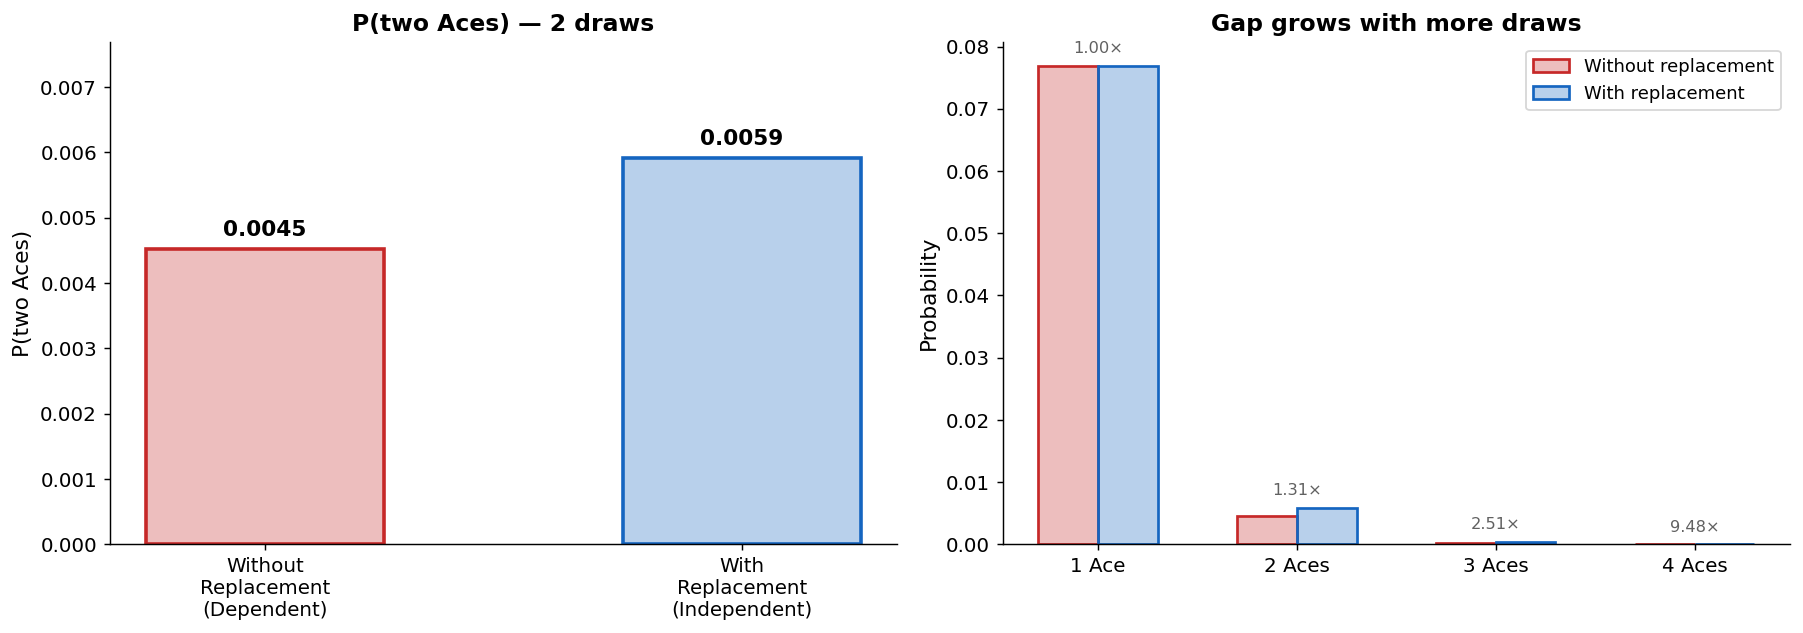

In [32]:
# --- Visual: bar comparison + how the gap grows with more draws ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Bar comparison for 2 Aces
ax = axes[0]
labels = ['Without\nReplacement\n(Dependent)', 'With\nReplacement\n(Independent)']
vals = [P_both_without, P_both_with]
colors = ['#C62828', '#1565C0']

bars = ax.bar(labels, vals, color=[to_rgba(c, 0.3) for c in colors],
              edgecolor=colors, lw=2, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('P(two Aces)', fontsize=12)
ax.set_title('P(two Aces) — 2 draws', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(vals) * 1.3)

# Panel 2: Gap grows with more sequential draws
ax = axes[1]
n_draws = range(1, 5)

p_with = []
p_without = []
for n in n_draws:
    # With replacement: (4/52)^n
    p_w = (4/52) ** n
    p_with.append(p_w)
    # Without replacement: 4/52 × 3/51 × 2/50 × ...
    p_wo = 1.0
    for i in range(n):
        p_wo *= (4 - i) / (52 - i)
    p_without.append(p_wo)

x = np.arange(len(list(n_draws)))
width = 0.3
bars1 = ax.bar(x - width/2, p_without, width, color=to_rgba('#C62828', 0.3),
               edgecolor='#C62828', lw=1.5, label='Without replacement')
bars2 = ax.bar(x + width/2, p_with, width, color=to_rgba('#1565C0', 0.3),
               edgecolor='#1565C0', lw=1.5, label='With replacement')

ax.set_xticks(x)
ax.set_xticklabels([f'{n} Ace{"s" if n > 1 else ""}' for n in n_draws])
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Gap grows with more draws', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

# Annotate ratio on last bar
for i, n in enumerate(n_draws):
    if p_without[i] > 0:
        ratio = p_with[i] / p_without[i]
        ax.text(i, max(p_with[i], p_without[i]) + 0.002,
                f'{ratio:.2f}×', ha='center', fontsize=9, color='#616161')

plt.tight_layout()
plt.show()

---
## 8 · Chain Rule — Both Directions

The chain rule can be applied in **either order**:

$$P(E \cap F) = P(E \mid F) \cdot P(F) = P(F \mid E) \cdot P(E)$$

Both give the **same result**. Choose whichever direction has the easier conditional probability.

In [33]:
# --- Both directions of the chain rule ---

# Example: bag with 3 red, 2 blue balls. Draw 2 without replacement.
# E = 1st ball red, F = 2nd ball red

print('Chain Rule — Both Directions')
print('=' * 55)
print('Bag: 3 red, 2 blue. Draw 2 without replacement.')
print('E = 1st red, F = 2nd red')
print()

# Direction 1: P(E ∩ F) = P(F|E) · P(E)
P_E_bag = 3/5
P_F_given_E_bag = 2/4  # after removing 1 red: 2 red left out of 4
P_EF_dir1 = P_F_given_E_bag * P_E_bag

print('Direction 1: P(E ∩ F) = P(F|E) · P(E)')
print(f'  P(E) = 3/5 = {P_E_bag:.4f}')
print(f'  P(F|E) = 2/4 = {P_F_given_E_bag:.4f}  (removed 1 red → 2 red in 4)')
print(f'  P(E ∩ F) = {P_F_given_E_bag:.4f} × {P_E_bag:.4f} = {P_EF_dir1:.4f}')
print()

# Direction 2: P(E ∩ F) = P(E|F) · P(F)
# P(F) = P(F|E)·P(E) + P(F|E^C)·P(E^C) = (2/4)(3/5) + (3/4)(2/5) = 6/20 + 6/20 = 12/20 = 3/5
P_F_bag = 3/5  # by symmetry: 2nd ball is red with same marginal prob
P_E_given_F_bag = P_EF_dir1 / P_F_bag  # from chain rule direction 1

print('Direction 2: P(E ∩ F) = P(E|F) · P(F)')
print(f'  P(F) = 3/5 = {P_F_bag:.4f}  (by symmetry: same marginal)')
print(f'  P(E|F) = P(E∩F)/P(F) = {P_EF_dir1:.4f}/{P_F_bag:.4f} = {P_E_given_F_bag:.4f}')
print(f'  P(E ∩ F) = {P_E_given_F_bag:.4f} × {P_F_bag:.4f} = {P_E_given_F_bag * P_F_bag:.4f}')
print()
print(f'Both directions give the same answer: {P_EF_dir1:.4f} ✓')

Chain Rule — Both Directions
Bag: 3 red, 2 blue. Draw 2 without replacement.
E = 1st red, F = 2nd red

Direction 1: P(E ∩ F) = P(F|E) · P(E)
  P(E) = 3/5 = 0.6000
  P(F|E) = 2/4 = 0.5000  (removed 1 red → 2 red in 4)
  P(E ∩ F) = 0.5000 × 0.6000 = 0.3000

Direction 2: P(E ∩ F) = P(E|F) · P(F)
  P(F) = 3/5 = 0.6000  (by symmetry: same marginal)
  P(E|F) = P(E∩F)/P(F) = 0.3000/0.6000 = 0.5000
  P(E ∩ F) = 0.5000 × 0.6000 = 0.3000

Both directions give the same answer: 0.3000 ✓


---
## 9 · Generalized Chain Rule

The chain rule extends to $n$ events by peeling off one event at a time, each conditioned on all the previous ones:

$$P(E_1 \cap E_2 \cap \cdots \cap E_n) = P(E_1) \cdot P(E_2 \mid E_1) \cdot P(E_3 \mid E_1 \cap E_2) \cdots P(E_n \mid E_1 \cap \cdots \cap E_{n-1})$$

In [34]:
# --- Generalized chain rule: drawing 5 cards, all hearts ---

print('Generalized Chain Rule: 5 Hearts in a Row')
print('=' * 55)
print('Draw 5 cards without replacement. P(all hearts)?')
print()

n_draws_cards = 5
total_hearts = 13
total_cards = 52

p_running = 1.0
factors = []

print(f'{"Draw":>5} {"Hearts left":>13} {"Cards left":>12} {"P(heart)":>10} {"Running P":>12}')
print('-' * 55)

for i in range(n_draws_cards):
    h_left = total_hearts - i
    c_left = total_cards - i
    p_i = h_left / c_left
    p_running *= p_i
    factors.append(f'{h_left}/{c_left}')
    eqn = ' × '.join(factors)
    cond = 'P(H₁)' if i == 0 else f'P(H{chr(8321+i)}|H₁{"" if i == 1 else "...H" + chr(8320+i)})'
    print(f'{i+1:>5} {h_left:>13} {c_left:>12} {p_i:>10.6f} {p_running:>12.8f}')

print(f'\nP(5 hearts) = ' + ' × '.join(factors) + f' = {p_running:.8f}')

# Verify with combinations
p_comb = comb(13, 5) / comb(52, 5)
print(f'\nVerification: C(13,5)/C(52,5) = {comb(13,5)}/{comb(52,5)} = {p_comb:.8f} ✓')

Generalized Chain Rule: 5 Hearts in a Row
Draw 5 cards without replacement. P(all hearts)?

 Draw   Hearts left   Cards left   P(heart)    Running P
-------------------------------------------------------
    1            13           52   0.250000   0.25000000
    2            12           51   0.235294   0.05882353
    3            11           50   0.220000   0.01294118
    4            10           49   0.204082   0.00264106
    5             9           48   0.187500   0.00049520

P(5 hearts) = 13/52 × 12/51 × 11/50 × 10/49 × 9/48 = 0.00049520

Verification: C(13,5)/C(52,5) = 1287/2598960 = 0.00049520 ✓


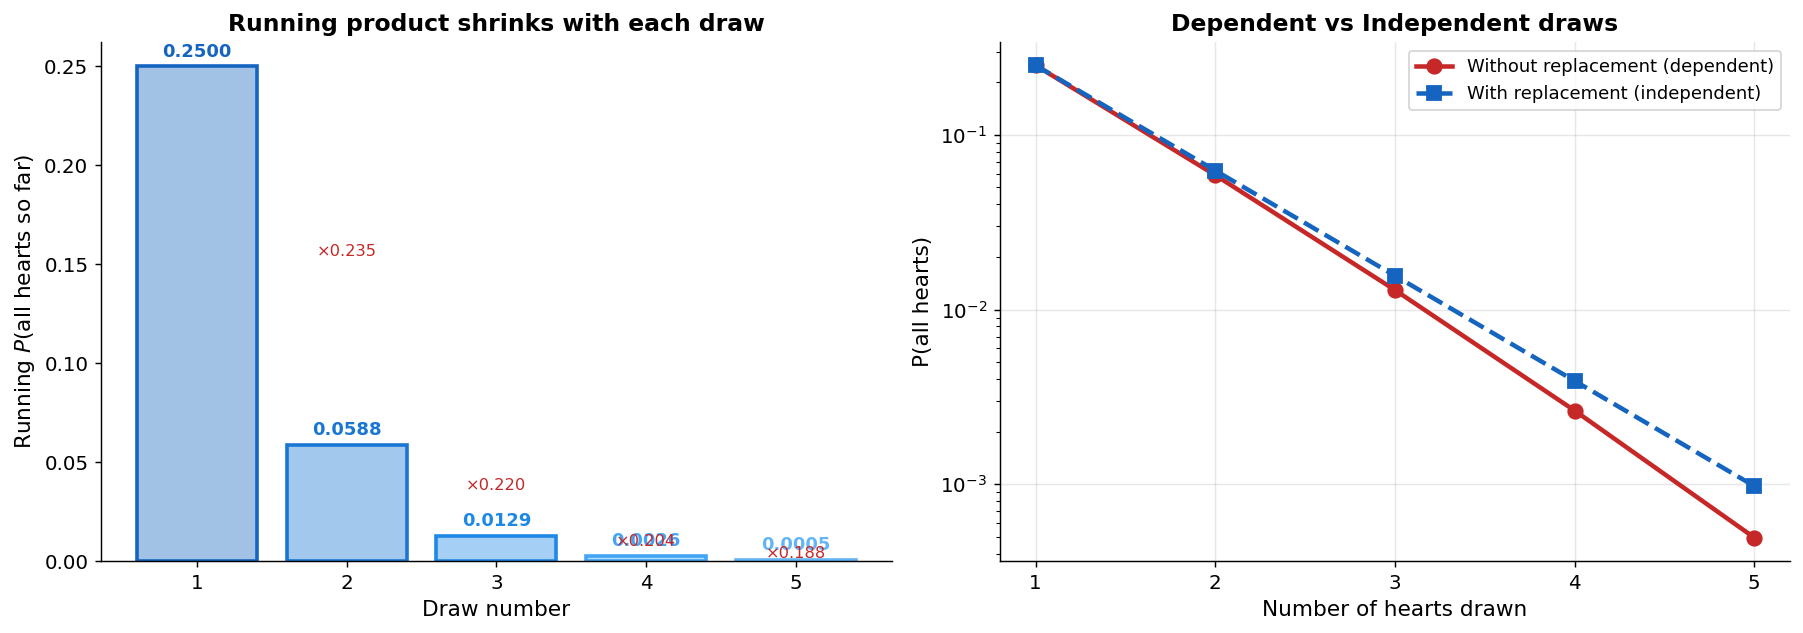

In [35]:
# --- Visual: probability draining with each dependent draw ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Factor-by-factor breakdown
ax = axes[0]
draw_nums = list(range(1, n_draws_cards + 1))
conditionals = [(total_hearts - i) / (total_cards - i) for i in range(n_draws_cards)]
running = [np.prod(conditionals[:i+1]) for i in range(n_draws_cards)]

# Running product as bars
colors_run = ['#1565C0', '#1976D2', '#1E88E5', '#42A5F5', '#64B5F6']
bars = ax.bar(draw_nums, running, color=[to_rgba(c, 0.4) for c in colors_run],
              edgecolor=colors_run, lw=2)

for i, (d, r) in enumerate(zip(draw_nums, running)):
    ax.text(d, r + 0.005, f'{r:.4f}', ha='center', fontsize=10, fontweight='bold',
            color=colors_run[i])
    if i > 0:
        ax.text(d, running[i-1] / 2 + running[i] / 2,
                f'×{conditionals[i]:.3f}', ha='center', fontsize=9, color='#C62828')

ax.set_xlabel('Draw number', fontsize=12)
ax.set_ylabel('Running $P$(all hearts so far)', fontsize=12)
ax.set_title('Running product shrinks with each draw',
             fontsize=13, fontweight='bold')
ax.set_xticks(draw_nums)
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: Compare dependent vs independent
ax = axes[1]
indep_running = [(13/52) ** i for i in range(1, n_draws_cards + 1)]

ax.plot(draw_nums, running, 'o-', color='#C62828', lw=2.5, markersize=8,
        label='Without replacement (dependent)')
ax.plot(draw_nums, indep_running, 's--', color='#1565C0', lw=2.5, markersize=8,
        label='With replacement (independent)')

ax.set_xlabel('Number of hearts drawn', fontsize=12)
ax.set_ylabel('P(all hearts)', fontsize=12)
ax.set_title('Dependent vs Independent draws', fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.set_xticks(draw_nums)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 10 · When to Multiply vs When to Use the Chain Rule

| Scenario | Formula | Example |
|----------|---------|--------|
| **Independent** events | $P(E \cap F) = P(E) \cdot P(F)$ | Two dice, coin flips |
| **Dependent** events | $P(E \cap F) = P(E \mid F) \cdot P(F)$ | Cards without replacement |
| **$n$ independent** events | $\prod P(E_i)$ | $n$ coin flips |
| **$n$ dependent** events | $P(E_1) \cdot P(E_2 \mid E_1) \cdots$ | $n$ draws without replacement |

**Key insight:** the product rule $P(E)\cdot P(F)$ is a *special case* of the chain rule when events are independent, since $P(E \mid F) = P(E)$.

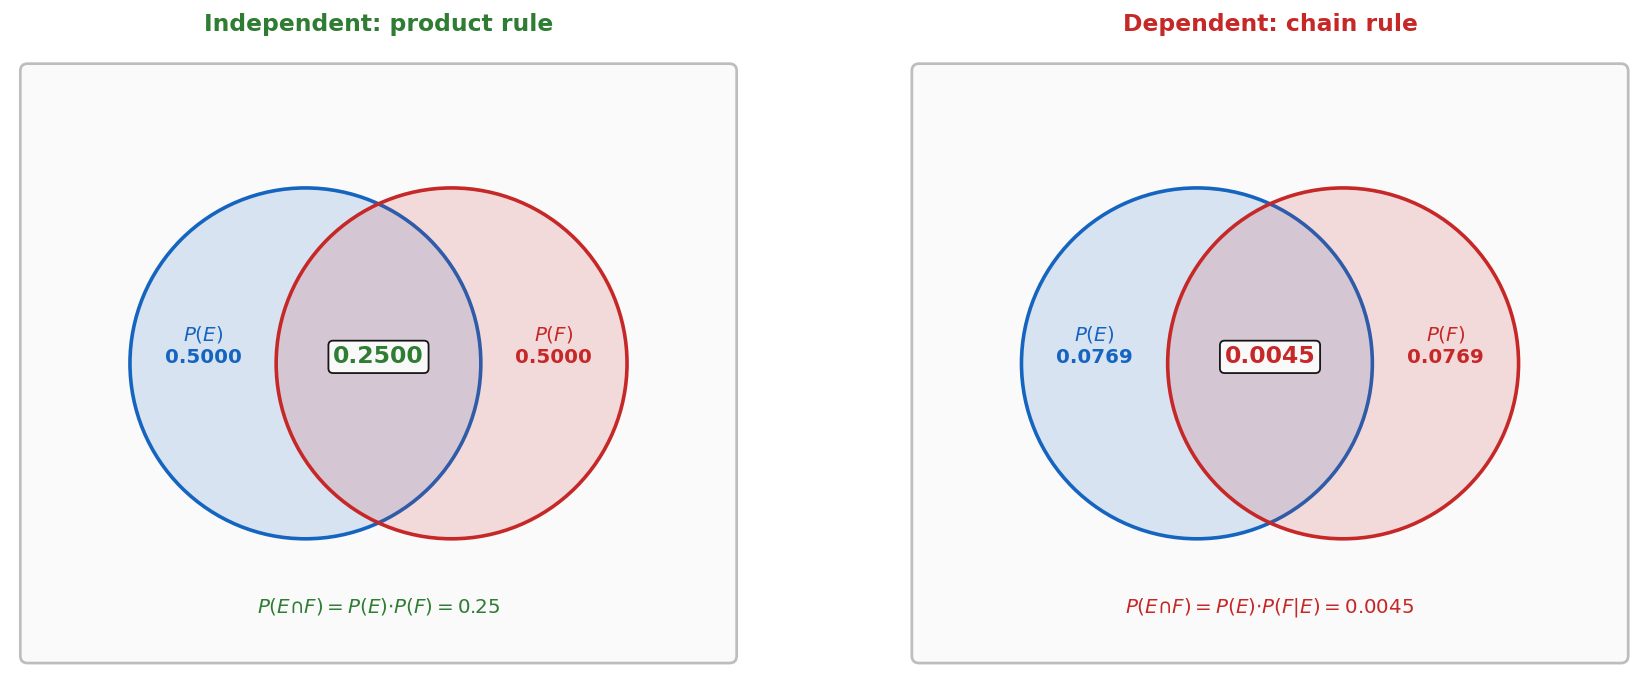

In [36]:
# --- Visual: Venn diagrams — independent vs dependent AND ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (title, p_e, p_f, p_ef, color, formula) in zip(axes, [
    ('Independent: product rule',
     0.50, 0.50, 0.25, '#2E7D32',
     '$P(E{\\cap}F) = P(E){\\cdot}P(F) = 0.25$'),
    ('Dependent: chain rule',
     4/52, 4/52, 12/2652, '#C62828',
     '$P(E{\\cap}F) = P(E){\\cdot}P(F|E) = 0.0045$'),
]):
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.2, 2.2)
    ax.set_aspect('equal')
    ax.axis('off')

    # Background
    rect = FancyBboxPatch((-2.4, -2.0), 4.8, 4.0, boxstyle='round,pad=0.05',
                          facecolor='#FAFAFA', edgecolor='#BDBDBD', lw=1.5)
    ax.add_patch(rect)

    # Circles
    ax.add_patch(Circle((-0.5, 0), 1.2, facecolor=to_rgba('#1565C0', 0.15),
                        edgecolor='#1565C0', lw=2))
    ax.add_patch(Circle((0.5, 0), 1.2, facecolor=to_rgba('#C62828', 0.15),
                        edgecolor='#C62828', lw=2))

    ax.text(-1.2, 0, f'$P(E)$\n{p_e:.4f}', ha='center', fontsize=11,
            fontweight='bold', color='#1565C0')
    ax.text(1.2, 0, f'$P(F)$\n{p_f:.4f}', ha='center', fontsize=11,
            fontweight='bold', color='#C62828')
    ax.text(0, 0, f'{p_ef:.4f}', ha='center', fontsize=13,
            fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

    ax.set_title(title, fontsize=13, fontweight='bold', color=color)
    ax.text(0, -1.7, formula, ha='center', fontsize=11, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 11 · Applied Example: System Reliability

A system has 3 **independent** components in **series** (all must work).
What is the probability the system works? This is a direct application of the product rule.

In [37]:
# --- Series system: all must work ---

reliabilities = [0.99, 0.95, 0.98]

p_system = np.prod(reliabilities)

print('Series System Reliability (Independent Components)')
print('=' * 55)

for i, r in enumerate(reliabilities, 1):
    print(f'  Component {i}: P(works) = {r:.2f}')

print(f'\nP(system works) = P(C₁ ∩ C₂ ∩ C₃)')
print(f'  = P(C₁) · P(C₂) · P(C₃)      (independence)')
print(f'  = {" × ".join(f"{r:.2f}" for r in reliabilities)}')
print(f'  = {p_system:.6f}')
print(f'  ≈ {p_system:.2%}')
print(f'\nThe weakest component (95%) drags the whole system down!')
print(f'System reliability is LESS than the weakest component.')

Series System Reliability (Independent Components)
  Component 1: P(works) = 0.99
  Component 2: P(works) = 0.95
  Component 3: P(works) = 0.98

P(system works) = P(C₁ ∩ C₂ ∩ C₃)
  = P(C₁) · P(C₂) · P(C₃)      (independence)
  = 0.99 × 0.95 × 0.98
  = 0.921690
  ≈ 92.17%

The weakest component (95%) drags the whole system down!
System reliability is LESS than the weakest component.


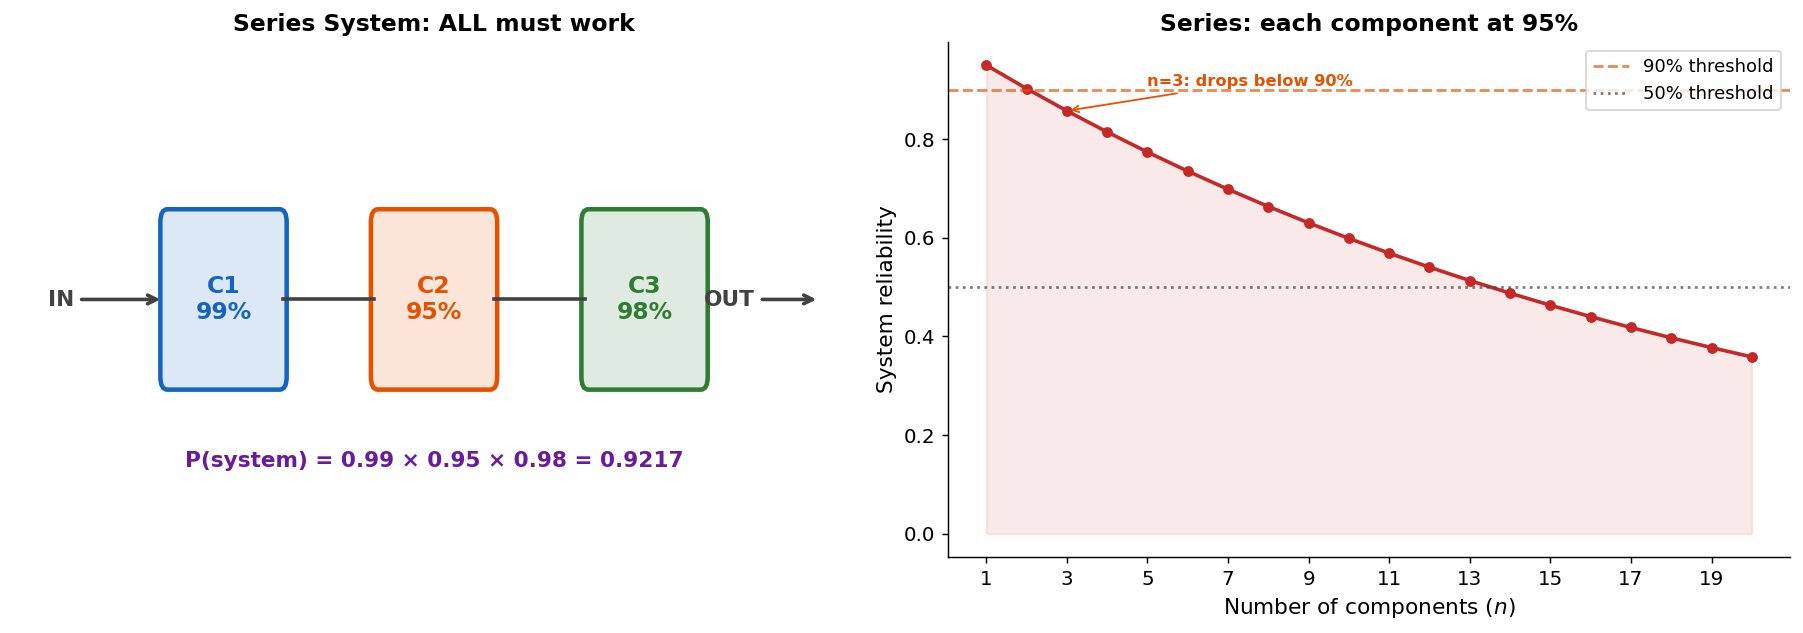

In [38]:
# --- Visual: series system + reliability curve ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: System diagram
ax = axes[0]
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 3)
ax.axis('off')

# Draw components in series
x_positions = [2, 5, 8]
colors_comp = ['#1565C0', '#E65100', '#2E7D32']

for i, (x, r, c) in enumerate(zip(x_positions, reliabilities, colors_comp)):
    rect = FancyBboxPatch((x - 0.8, 0.4), 1.6, 1.2,
        boxstyle='round,pad=0.1', facecolor=to_rgba(c, 0.15),
        edgecolor=c, lw=2.5)
    ax.add_patch(rect)
    ax.text(x, 1.0, f'C{i+1}\n{r:.0%}', ha='center', va='center',
            fontsize=13, fontweight='bold', color=c)

    # Connecting lines
    if i > 0:
        ax.plot([x_positions[i-1] + 0.85, x - 0.85], [1.0, 1.0],
                color='#424242', lw=2)

# Input/output arrows
ax.annotate('IN', xy=(x_positions[0] - 0.85, 1.0), xytext=(-0.5, 1.0),
            fontsize=12, fontweight='bold', color='#424242',
            arrowprops=dict(arrowstyle='->', color='#424242', lw=2),
            va='center')
ax.annotate('OUT', xy=(10.5, 1.0), xytext=(x_positions[-1] + 0.85, 1.0),
            fontsize=12, fontweight='bold', color='#424242',
            arrowprops=dict(arrowstyle='->', color='#424242', lw=2),
            va='center')

ax.text(5, -0.3, f'P(system) = {" × ".join(f"{r:.2f}" for r in reliabilities)} = {p_system:.4f}',
        ha='center', fontsize=12, fontweight='bold', color='#6A1B9A')

ax.set_title('Series System: ALL must work', fontsize=13, fontweight='bold')

# Panel 2: How system reliability drops with n components
ax = axes[1]
component_r = 0.95
n_comps = np.arange(1, 21)
system_r = component_r ** n_comps

ax.plot(n_comps, system_r, 'o-', color='#C62828', lw=2, markersize=5)
ax.axhline(0.90, ls='--', color='#E65100', lw=1.5, alpha=0.7, label='90% threshold')
ax.axhline(0.50, ls=':', color='#424242', lw=1.5, alpha=0.7, label='50% threshold')

ax.fill_between(n_comps, system_r, alpha=0.1, color='#C62828')
ax.set_xlabel('Number of components ($n$)', fontsize=12)
ax.set_ylabel('System reliability', fontsize=12)
ax.set_title(f'Series: each component at {component_r:.0%}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(n_comps[::2])

# Annotate crossings
n_90 = int(np.ceil(np.log(0.90) / np.log(component_r)))
n_50 = int(np.ceil(np.log(0.50) / np.log(component_r)))
ax.annotate(f'n={n_90}: drops below 90%', xy=(n_90, component_r**n_90),
            xytext=(n_90 + 2, component_r**n_90 + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='#E65100'),
            color='#E65100', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 12 · Monte Carlo Verification

Let's verify both the product rule (independent) and the chain rule (dependent) with simulation.

In [39]:
# --- Monte Carlo: verify product rule vs chain rule ---

N_sim = 500_000
rng = np.random.default_rng(42)

# --- Test 1: Independent (two dice) ---
die1 = rng.integers(1, 7, size=N_sim)
die2 = rng.integers(1, 7, size=N_sim)

E_sim = die1 % 2 == 0          # die1 even
F_sim = die2 >= 4               # die2 ≥ 4
EF_sim = E_sim & F_sim

print(f'Monte Carlo Verification ({N_sim:,} trials)')
print('=' * 55)

print(f'\n--- Independent: die₁ even AND die₂ ≥ 4 ---')
print(f'  Simulated P(E ∩ F) = {EF_sim.mean():.4f}')
print(f'  P(E)·P(F) = {E_sim.mean():.4f} × {F_sim.mean():.4f} = {E_sim.mean() * F_sim.mean():.4f}')
print(f'  Exact = 0.5 × 0.5 = 0.2500')

# --- Test 2: Dependent (cards without replacement) ---
deck_indices = np.arange(52)
# 0-3 are Aces
ace1_count = 0
both_aces_count = 0

# Vectorized: draw two cards per trial
cards = np.array([rng.choice(52, size=2, replace=False) for _ in range(N_sim)])
card1_ace = cards[:, 0] < 4
card2_ace = cards[:, 1] < 4
both_ace = card1_ace & card2_ace

print(f'\n--- Dependent: two Aces without replacement ---')
print(f'  Simulated P(Ace₁ ∩ Ace₂) = {both_ace.mean():.6f}')
print(f'  Chain rule: 4/52 × 3/51 = {4/52 * 3/51:.6f}')
print(f'  If independent (wrong): 4/52 × 4/52 = {(4/52)**2:.6f}')
print(f'\n  Simulation matches chain rule, not product rule ✓')

Monte Carlo Verification (500,000 trials)

--- Independent: die₁ even AND die₂ ≥ 4 ---
  Simulated P(E ∩ F) = 0.2486
  P(E)·P(F) = 0.4996 × 0.4992 = 0.2494
  Exact = 0.5 × 0.5 = 0.2500

--- Dependent: two Aces without replacement ---
  Simulated P(Ace₁ ∩ Ace₂) = 0.004524
  Chain rule: 4/52 × 3/51 = 0.004525
  If independent (wrong): 4/52 × 4/52 = 0.005917

  Simulation matches chain rule, not product rule ✓


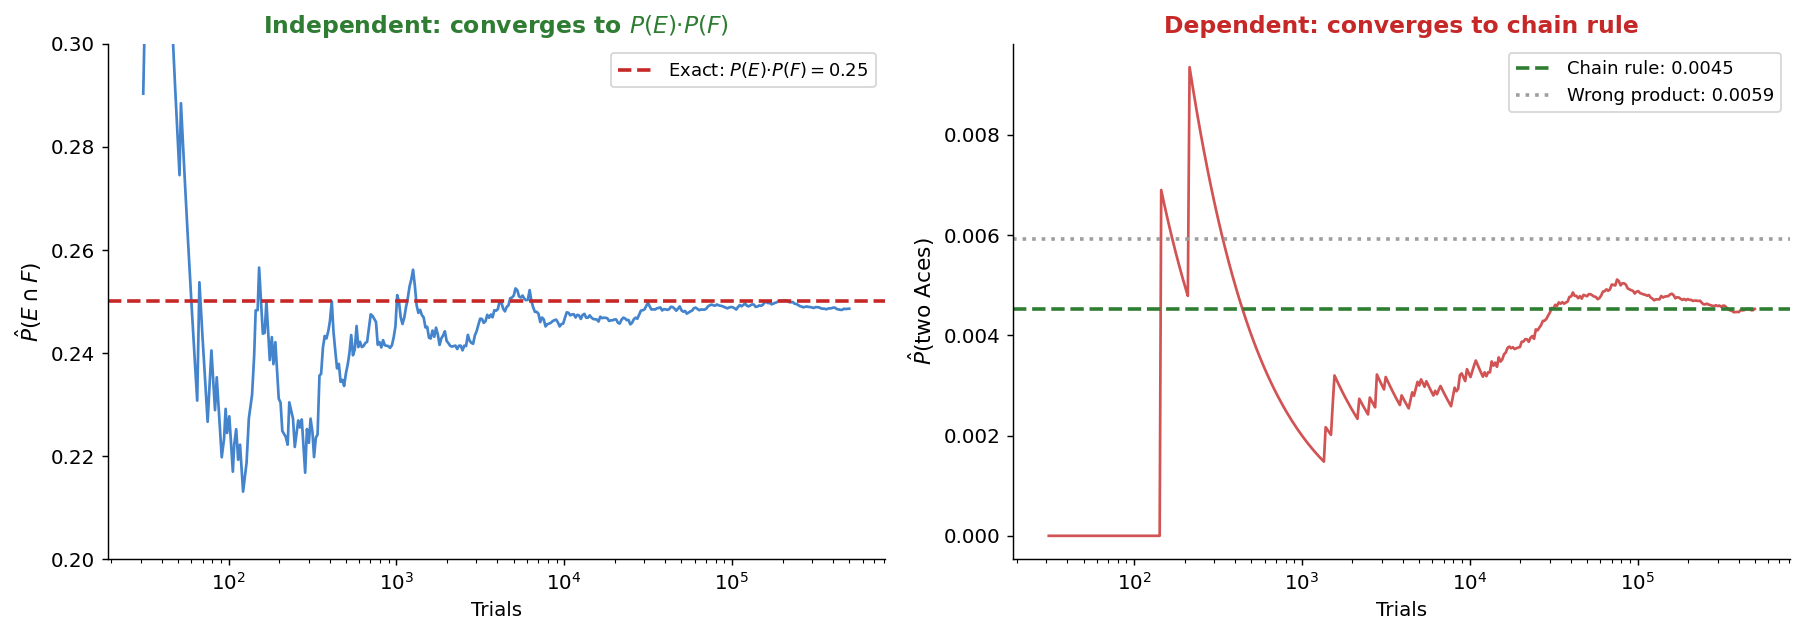

In [40]:
# --- Visual: convergence of Monte Carlo estimates ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

checkpoints = np.unique(np.logspace(1.5, np.log10(N_sim), 400).astype(int))

# Panel 1: Independent (dice)
ax = axes[0]
cum_EF = np.cumsum(EF_sim)
ratio_dice = cum_EF[checkpoints - 1] / checkpoints

ax.plot(checkpoints, ratio_dice, color='#1565C0', lw=1.5, alpha=0.8)
ax.axhline(0.25, color='#C62828', ls='--', lw=2, label='Exact: $P(E)·P(F) = 0.25$')
ax.set_xscale('log')
ax.set_xlabel('Trials', fontsize=11)
ax.set_ylabel('$\\hat{P}(E \\cap F)$', fontsize=12)
ax.set_title('Independent: converges to $P(E)·P(F)$',
             fontsize=13, fontweight='bold', color='#2E7D32')
ax.legend(fontsize=10)
ax.set_ylim(0.20, 0.30)
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: Dependent (cards)
ax = axes[1]
cum_aces = np.cumsum(both_ace)
ratio_cards = cum_aces[checkpoints - 1] / checkpoints

exact_chain = 4/52 * 3/51
wrong_product = (4/52) ** 2

ax.plot(checkpoints, ratio_cards, color='#C62828', lw=1.5, alpha=0.8)
ax.axhline(exact_chain, color='#2E7D32', ls='--', lw=2,
           label=f'Chain rule: {exact_chain:.4f}')
ax.axhline(wrong_product, color='#9E9E9E', ls=':', lw=2,
           label=f'Wrong product: {wrong_product:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Trials', fontsize=11)
ax.set_ylabel('$\\hat{P}(\\text{two Aces})$', fontsize=12)
ax.set_title('Dependent: converges to chain rule',
             fontsize=13, fontweight='bold', color='#C62828')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 13 · Summary

| Concept | Formula | When to use |
|---------|---------|-------------|
| **Product Rule** | $P(E \cap F) = P(E) \cdot P(F)$ | Events are **independent** |
| **Chain Rule** | $P(E \cap F) = P(E \mid F) \cdot P(F)$ | **Always** works (general) |
| **Symmetry** | $P(E \mid F) \cdot P(F) = P(F \mid E) \cdot P(E)$ | Use whichever direction is easier |
| **Generalized (indep.)** | $\prod_{i=1}^{n} P(E_i)$ | $n$ independent events |
| **Generalized (chain)** | $P(E_1)\!\cdot\!P(E_2 \mid E_1)\!\cdots\!P(E_n \mid E_1\!\cap\!\cdots\!\cap\!E_{n-1})$ | $n$ events (any) |

**Key insight:** The product rule is a special case of the chain rule. When in doubt, use the chain rule.